### __Predicting Airbnb Listing Prices in Sydney__

--- 
## Task 4: Fit and Tune Prediction Models/ Produce predictions


### Overview

#### Breakdown of the general procedure:

**1. Load Data**
- Load cleaned dataset from `data/processed/cleaned_train.csv`.
- Split into `train` and `test` sets.

**2. Set up Cross-Validation function**
- Evaluate a model on multiple subsets of data.

**3. Baseline Model (Linear Regression)**
- Conduct LR model as the baseline model for comparison. 

**4. Train Multiple Models**
- Linear Regression (baseline).
- Decision Tree (simple tree-based model).
- Random Forest (strong tree ensemble model).
- Gradient Boosting, XGBoost (powerful boosting methods).

**5. Hyperparameter Tuning**
- Uses GridSearchCV to find the best parameters of Regression Models. 

**6. Bayesian Optimization for Faster Tuning**
- Uses BayesSearchCV to fater tune Regression Models. 

**7. Compare Model Performance**
- Compare R² scores, MAE and RMSE of each model.
- Plots bar chart of model performance.

**8. Save the Best Model**
- Identifies the best-performing model.
- Saves it as `results/best_model.pkl`.

**9. Generate Predictions**
- Perform the saved best model on the test dataset to predict the `price`.

#### Models Selection Breakdown

Since we're predicting **Airbnb listing prices** (a continuous numerical target), this is a regression problem. Based on the nature of given datasets and typical challenges in price prediction, I selected a mix of traditional ML models and ensemble learning methods to balance interpretability, predictive power, and generalization.

To assist the hyperparameters tuning process, we utilize `K-fold Cross Validation` and `GridSearchCV` method. Specifically, we select important parameters and set a suitable range for them so that the Random Search can identify the best performance with optimal parameters. For the _K-fold Cross Validation_ method, its purpose is to assess how well a ML model can generalize to unseen data by training and testing on different parts of the dataset multiple times and prevent overfitting.

#### Models Selection Strategy
1. Start with a simple model (`Linear Regression`) to establish a baseline.
2. Use `Decision Trees` to see how non-linear relationships improve results.
3. Apply `Ensemble Methods (Random Forest, Gradient Boosting)` to enhance predictive power.
4. Use `Advanced Boosting Models (XGBoost)` for optimized performance.
5. **Fine-tune hyperparameters** using `GridSearchCV` & `Bayesian Optimization`.

### 1. Import processed data

In [90]:
# Import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Models 
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
import xgboost as xgb

# Bayesian Optimization
from skopt import BayesSearchCV

In [91]:
# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Configure seaborn aesthetics
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

Use relative paths instead of hardcoded paths to enable universal uses:

In [92]:
# Define correct file paths for loading the datasets
train_file_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/data/processed/feature_engineered_train.csv"
test_file_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/data/processed/feature_engineered_test.csv"

In [93]:
# Retrieve the engineered datasets
df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

As the `price` variable in the case with real estate might have a **skewed distribution**. 

Here we used `np.log1p(x)` to log-transform the target variable to make it normally distributed, which can improve the model. Also, this method ensures that even if price = 0, it doesn't cause errors.

In [94]:
# Log-transforming the price to stabilize variance
df_train["log_price"] = np.log1p(df_train["price"])

Generating different subsets of independent variables and the target variable:

In [95]:
# Select features and target variable
features = [col for col in df_train.columns if col not in ["price", "log_price"]]

X = df_train[features]
y = df_train["log_price"]

Uses `train_test_split` with `random_state=42`, ensuring reproducibility:

In [96]:
# Split into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Last check for missing values or infinite values in the training set: 

In [97]:
# Check for NaN values
print("NaN values in X_train:", np.isnan(X_train).sum().sum())
print("NaN values in y_train:", np.isnan(y_train).sum())

# Check for infinite values
print("Infinite values in X_train:", np.isinf(X_train).sum().sum())
print("Infinite values in y_train:", np.isinf(y_train).sum())

NaN values in X_train: 0
NaN values in y_train: 0
Infinite values in X_train: 0
Infinite values in y_train: 0


All missing values are clear, we can start the modelling process.

### 2. Cross-Validation Function

To ensure our model generalizes well to unseen data, we use **K-Fold Cross-Validation (CV)**. This method splits the dataset into multiple folds, trains the model on some folds, and tests it on the remaining ones. 

- We define a **5-fold cross-validation strategy** using `KFold`, ensuring reproducibility with `random_state=42`.
- The `evaluate_model` function:
  - Computes **cross-validation scores** using the R² metric.
  - Prints the **mean R² score** and **standard deviation** to assess model stability.
  - Returns the mean R² score for further evaluation.

This approach helps us avoid overfitting and provides a robust estimate of model performance.


In [98]:
# Define cross-validation strategy (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Helper function to evaluate models 
def evaluate_model(model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2", n_jobs=-1)
    print(f"{model.__class__.__name__}: Mean R² = {scores.mean():.3f} | Std = {scores.std():.3f}")
    return scores.mean()

### 3. Baseline Model (Linear Regression)

Multiple linear regression (MLR) uses several explanatory variables to predict the outcome of a dependent variable. The goal of multiple linear regression is to model the linear relationship between the explanatory (independent) variables and response (dependent) variables.

In [99]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)
print(f"Linear Regression - R²: {r2_score(y_test, y_pred_lr):.3f}")

Linear Regression - R²: 0.682


### 4. Train Multiple Models with Cross-Validation

In this step, we train multiple regression models and evaluate their performance using **5-fold cross-validation**. 

- We define a dictionary of models, including:
  - **Decision Tree**
  - **Random Forest**
  - **Gradient Boosting**
  - **XGBoost**

- Each model is trained and evaluated using the previously defined `evaluate_model` function.
- The results are stored in a **DataFrame** and sorted based on the **Mean R² score**, allowing us to compare model performance.

This process helps us determine which model generalizes best to our dataset before further fine-tuning.


In [100]:
# Define multiple models with their parameters 
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

In [101]:
# Store cross-validation results
cv_results = {name: evaluate_model(model, X_train, y_train) for name, model in models.items()}

DecisionTreeRegressor: Mean R² = 0.642 | Std = 0.015
RandomForestRegressor: Mean R² = 0.712 | Std = 0.017
GradientBoostingRegressor: Mean R² = 0.736 | Std = 0.011
XGBRegressor: Mean R² = 0.737 | Std = 0.014


In [ ]:
# Store the results in a DataFrame and sort them by the mean R²
df_cv_results = pd.DataFrame(cv_results.items(), columns=["Model", "Mean R²"]).sort_values(by="Mean R²", ascending=False)
df_cv_results

,Model,Mean R²
3,XGBoost,0.736528
2,Gradient Boosting,0.735739
1,Random Forest,0.712421
0,Decision Tree,0.641502


### 5. Hyperparameter Tuning with GridSearchCV

Selecting appropriate hyperparameter values for models like Random Forest, Gradient Boosting and XGBoost is crucial for optimizing performance. Those ranges of values for each parameter of each model is carefully selected with a logic: 
- **Start with Defaults**: Begin with default settings to establish a baseline.
- **Incremental Testing**: Adjust one parameter at a time to observe its impact.
- **Cross-Validation**: Use techniques like GridSearchCV to systematically explore combinations.
- **Computational Resources**: Balance the depth and number of trees with available resources to manage training time.

In [ ]:
# Set up parameter grids for hyperparameter tuning
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 300, 500],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    },
    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 6, 9],
    },
}

In [104]:
# Current state of all applied models
models

{'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)}

In [105]:
# Hyperparameter tuning for all models
best_models = {}

models = {k: v for k, v in models.items() if k != "Decision Tree"}

for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring="r2", n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best {name} Parameters: {grid_search.best_params_}")


🔍 Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}

🔍 Tuning Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Gradient Boosting Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}

🔍 Tuning XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best XGBoost Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500}


### 6. Bayesian Optimization for Faster Tuning

In our Airbnb price prediction project, `Bayesian Optimization` serves as an advanced method for `Hyperparameter Tuning`. Unlike traditional approaches like grid or random search, `Bayesian Optimization` builds a probabilistic model of the objective function and uses this model to select the most promising hyperparameters to evaluate next.

In [106]:
# Set up parameter grids for bayesian optimization
bayes_params = {
    "Random Forest": {
        "n_estimators": (100, 500),
        "max_depth": (5, 50),
        "min_samples_split": (2, 10),
    },
    "XGBoost": {
        "n_estimators": (100, 500),
        "learning_rate": (0.01, 0.3, "log-uniform"),
        "max_depth": (3, 9),
    },
}

In [107]:
# Bayesian optimization for all models
bayes_best_models = {}

for name in ["Random Forest", "XGBoost"]:
    print(f"\n🚀 Bayesian Optimization for {name}...")
    bayes_opt = BayesSearchCV(models[name], bayes_params[name], n_iter=20, cv=5, scoring="r2", n_jobs=-1, verbose=1)
    bayes_opt.fit(X_train, y_train)
    bayes_best_models[name] = bayes_opt.best_estimator_
    print(f"✅ Best {name} Parameters (Bayesian): {bayes_opt.best_params_}")


🚀 Bayesian Optimization for Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 

### 7. Model Comparison

Now that we have completed optimised the models with **GridSearchCV** and **Bayesian Optimization**, we can decide the best models found by both methods. 

In [108]:
# Compare GridSearchCV vs. Bayesian Optimization results to determine which tuning method worked best.
final_models = {**best_models, **bayes_best_models}
final_models

{'Random Forest': RandomForestRegressor(max_depth=10, min_samples_split=7, n_estimators=319,
                       random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(learning_rate=0.01, max_depth=5, n_estimators=500,
                           random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.016724509424621246,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
   

In [109]:
# Evaluate the final models on the test set with R²
results = {name: r2_score(y_test, model.predict(X_test)) for name, model in final_models.items()}
df_results = pd.DataFrame(results.items(), columns=["Model", "R² Score"]).sort_values(by="R² Score", ascending=False)
df_results

,Model,R² Score
1,Gradient Boosting,0.751335
2,XGBoost,0.750105
0,Random Forest,0.746131


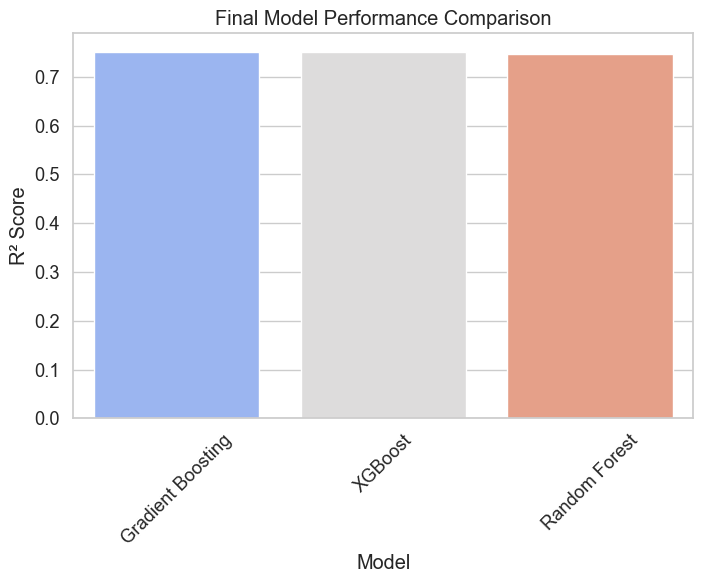

In [110]:
# Visualize the final model performance comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=df_results, x="Model", y="R² Score", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Final Model Performance Comparison")
plt.show()

**Compare other metrics:**

R² alone doesn’t always tell the full story. Try Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE):

In [111]:
# Store all metrics' results in a DataFrame and sort them by R²
results = {}
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        "R² Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

df_results = pd.DataFrame.from_dict(results, orient="index").sort_values(by="R² Score", ascending=False)
df_results

,R² Score,MAE,RMSE
Gradient Boosting,0.751335,0.336321,0.435510
XGBoost,0.750105,0.335961,0.436586
Random Forest,0.746131,0.336762,0.440043


**Which Model to Choose?**

- `Gradient Boosting` has the **highest R²** (slightly better than XGBoost).
- `XGBoost` has the **lowest MAE**, meaning it makes _fewer absolute errors_.

Both **GBR & XGBoost** are very close, but since `Gradient Boosting` has a **slightly better R²**, I’d consider it the best standalone model.

### 8. Save the Best Model

It's time to save the chosen best model for future use!

In [112]:
# Define the save path
save_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists

In [115]:
# Save the best model
best_model_name = df_results.index[0]         # Get the best model name
best_model = final_models[best_model_name]    # Get the best model object

In [118]:
# Ensure the chosen model is Gradient Boosting
assert best_model_name == "Gradient Boosting"
print(f"\nBest model saved: {best_model_name}")


Best model saved: Gradient Boosting


In [119]:
# Dump the best model to a .pkl file
file_name = f"best_model_{best_model_name}.pkl"
file_path = os.path.join(save_path, file_name)
joblib.dump(best_model, file_path)
print(f"Best model '{best_model_name}' saved successfully at: {file_path}")

Best model 'Gradient Boosting' saved successfully at: C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results\best_model_Gradient Boosting.pkl


### 9. Generate Predictions

Now we can apply the chosen best model on the test dataset to produce predictions of `price`.

In [122]:
# Make predictions
predictions = best_model.predict(df_test)

In [123]:
# Save predictions to CSV
df_test["Predicted_Price"] = predictions
predictions_file_name = "test_predictions.csv"
predictions_file_path = Path(save_path) / predictions_file_name

df_test.to_csv(predictions_file_path, index=False)

### Alternative Method 1 - Pipeline

In [ ]:
# Define a faster model setup
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
    }
}

# Train models
model_results = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    opt = RandomizedSearchCV(pipeline, param_distributions[model_name], n_iter=10, cv=3, scoring="r2", random_state=42, n_jobs=-1)
    opt.fit(X_train, y_train)
    best_pipeline = opt.best_estimator_
    
    # Compute evaluation metrics
    y_pred = best_pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error
    
    model_results[model_name] = {"R²": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape}


# Convert results to DataFrame
results_df = pd.DataFrame(model_results).T.sort_values(by="R2 Score", ascending=False)
print("Model Performance Comparison:")
display(results_df)

# Define the save path
save_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists

# Save the best model
best_model_name = results_df.index[0]  # Get the best model name
best_model = models[best_model_name]   # Get the best model object

file_name = f"best_pipeline_{best_model_name}.pkl"
file_path = os.path.join(save_path, file_name)
joblib.dump(best_model, file_path)

print(f"Best model '{best_model_name}' saved successfully at: {file_path}")


# Visualization
plt.figure(figsize=(10,5))
sns.barplot(x=results_df.index, y=results_df["R2 Score"], palette="viridis")
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()

# # Load the best model pipeline
# best_model_file = f"/mnt/data/best_pipeline_{results_df.index[0]}.pkl"
# best_pipeline = joblib.load(best_model_file)

# Make predictions
predictions = best_model.predict(df_test)

# Save predictions to CSV
df_test["Predicted_Price"] = predictions
predictions_file_path = "/mnt/data/test_predictions.csv"
df_test.to_csv(predictions_file_path, index=False)

# Return the path for download
predictions_file_path


### Alternative Method 2 - Stacking Model

As the `price` variable in the case with real estate might have a **skewed distribution**. 

Here we used `np.log1p(x)` to log-transform the target variable to make it normally distributed, which can improve the model. Also, this method ensures that even if price = 0, it does not cause errors.

In [ ]:
# Log-transform the price to stabilize variance
df_train["log_price"] = np.log1p(df_train["price"])

Generating different subsets of independent variables and the target variable:

In [ ]:
# Select features and target variable
features = [col for col in df_train.columns if col not in ["price", "log_price"]]
X = df_train[features]
y = df_train["log_price"]

Splitting the `df_train` dataframe into training and testing sets:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Now we define base models for stacking with 2 **ensemble models** as base learners: 
- **Random Forest** (`rf`): Uses multiple decision trees and averages their predictions.
- **Gradient Boosting** (`gbr`): An iterative boosting model that improves errors of previous models.

In [ ]:
base_models = [
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("gbr", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

Defining the Meta-Model: 
- `RidgeCV()` is a Ridge Regression model with built-in cross-validation.
- It is used as the **meta-model** that learns from the outputs of base models.

In [ ]:
# Meta-model for stacking
meta_model = RidgeCV()

Defining the Stacking Model: 
- **Stacking Regressor**: Combines multiple base models and feeds their predictions into a final estimator (meta-model).
- `estimators=base_models` → Uses Random Forest & Gradient Boosting as base models.
- `final_estimator=meta_model` → Ridge Regression is used to combine base model predictions.
- `n_jobs=-1` → Uses all available CPU cores for parallel processing (faster training).

In [ ]:
# Stacking model 
stacked_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, n_jobs=-1)

Training the Stacking model: Fits the stacked ensemble model on the **training dataset**.

In [ ]:
# Train the model 
stacked_model.fit(X_train, y_train)

StackingRegressor(estimators=[('rf', RandomForestRegressor(random_state=42)),
                              ('gbr',
                               GradientBoostingRegressor(random_state=42))],
                  final_estimator=RidgeCV(alphas=array([ 0.1,  1. , 10. ])),
                  n_jobs=-1)

Making Predictions: Uses the trained model to predict values for the **test dataset**.

In [ ]:
# Produce predictions
y_pred = stacked_model.predict(X_test)

Evaluating results with different metrics: 
- `r2_score` → Measures how well the model explains variance in the target variable.
    - Closer to 1 means a better model.
- `mean_absolute_error (MAE)` → Measures average absolute errors (lower is better).
- `root mean squared error (RMSE)` → Measures standard deviation of residuals (lower is better).

In [ ]:
# Evaluating results
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Output results
r2, mae, rmse

(0.7515355298757688, 0.33513748322555126, 0.43533396621185033)

✅ If R² improves significantly over individual models, our stacking model is the best! 🚀

These new results show a significant improvement in __R²__, increasing to approximately **0.75**, which is much better than your previous results. The lower MAE and RMSE also indicate reduced prediction errors.